# 16_信息论-交叉熵

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家聊聊什么是交叉熵。

简单一句话：**交叉熵是用来衡量两个概率分布之间有多不一样的一种方法。**

举个例子，老师让学生猜明天的天气情况。

你给出自己的预测：

- 晴天的概率是 70%
- 阴天的概率是 20%
- 下雨的概率是 10%

然后第二天真的天气情况出来了：**是「下雨」！**

那现在问题来了：你预测得准吗？你有多「错」？

这时候我们可以用交叉熵来「惩罚」你预测的不准程度。

### 交叉熵是怎么做这件事的？

交叉熵专门用来衡量「你的预测分布」和「真实分布」之间的差距。

在上面这个例子里：

- 你的预测分布是：`[0.7, 0.2, 0.1]`
- 真实的情况（实际是下雨）对应的分布是：`[0, 0, 1]`（也叫 one-hot 编码）

交叉熵的公式其实就是：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
交叉熵 = - ∑ (真实值 × log(预测值))
```

对上面的例子来说就是：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
交叉熵 = - (0×log(0.7) + 0×log(0.2) + 1×log(0.1))  
       = - log(0.1)
       = 惩罚值 = 2.30（左右）
```

你预测「下雨」的概率很低（0.1），结果却真的下雨了，所以惩罚很大。

交叉熵的核心：

- 如果你「预测得越准」，交叉熵的值就**越小**。
- 如果你「预测得越差」，交叉熵的值就**越大**。
- 所以：**模型训练的目标，就是让交叉熵越来越小**！

交叉熵几乎是**分类模型**（比如图像识别、情感分类、语言模型等）中最常见的损失函数，用来告诉模型：「你到底预测得准不准」。

和熵有什么关系？

「熵」本身表示：一个系统的**不确定性**。

「交叉熵」表示：你用错误的预测去解释这个系统时，你的平均「困惑程度」。

所以交叉熵可以理解为：「你带着错觉去看真相，结果有多困惑」。

## 原理详解

### 熵（Entropy）

熵表示一个概率分布的不确定性，定义如下：


$$
H(P) = - \sum_{i} p_i \log p_i
$$


- 其中 $P = \{p_1, p_2, ..., p_n\}$ 是一个概率分布（例如类别分布）。
- 熵越大，代表系统越“不可预测”。

如果某事件概率很平均（如每个类别都是 1/3），你对结果很难猜 → 熵高。

如果某事件几乎确定（如某类别概率接近1），你几乎能猜中 → 熵低。

### 交叉熵

交叉熵衡量两个概率分布之间的差异：


$$
H(P, Q) = - \sum_{i} p_i \log q_i
$$


其中：

- $P = \{p_1, p_2, ..., p_n\}$：真实分布（ground truth）。
- $Q = \{q_1, q_2, ..., q_n\}$：预测分布（模型的输出）。
- $q_i$ 必须满足 $0 < q_i \le 1$，且 $\sum q_i = 1$。

---

### 交叉熵的推导过程

#### 信息量

某个事件 $x_i$ 发生的信息量定义为：


$$
I(x_i) = -\log q_i
$$


越不可能发生的事件（$q_i$ 越小），其信息量越大。  
如果模型预测“它几乎不会发生”，但它发生了，损失会很大。

#### 期望信息量 → 交叉熵

如果我们想知道模型对真实分布 $P$ 产生的平均信息量：


$$
H(P, Q) = \mathbb{E}_{x \sim P}[ -\log Q(x) ] = - \sum_{i} p_i \log q_i
$$


这就是交叉熵。

### 交叉熵与熵、KL 散度的关系

#### KL 散度（相对熵）

KL 散度衡量两个分布 $P$ 和 $Q$ 的差异程度：


$$
D_{\mathrm{KL}}(P \| Q) = \sum_{i} p_i \log \frac{p_i}{q_i}
$$


可以展开为：


$$
D_{\mathrm{KL}}(P \| Q) = H(P, Q) - H(P)
$$


这意味着：

- 交叉熵 = 熵 + KL散度
- 最小化交叉熵 = 同时让模型尽量正确（熵不变）+ 分布差异尽量小（KL越小越好）

### 分类任务中的交叉熵

#### 多分类（one-hot + softmax）

如果真实标签是 one-hot 编码，如类别为 $k$，则 $p_k = 1$，其余为 0。

交叉熵简化为：


$$
H(P, Q) = - \log q_k
$$


也就是模型给真实标签 $k$ 预测的概率 $q_k$ 越大，损失越小。

#### 二分类

- 实际标签 $y \in \{0, 1\}$
- 模型预测概率 $\hat{y} = q$

损失函数为：


$$
H(y, \hat{y}) = - \left( y \log \hat{y} + (1 - y) \log (1 - \hat{y}) \right)
$$


推理方式：

- 如果真实是1，第一项保留，第二项为0 → 惩罚 $\log \hat{y}$。
- 如果真实是0，第一项为0，第二项保留 → 惩罚 $\log (1 - \hat{y})$。

### 交叉熵使用流程

#### 步骤 1：前向传播

- 模型输出 logits → 用 softmax 得到概率分布 $Q$

#### 步骤 2：计算损失

- 使用交叉熵公式：$-\sum_i p_i \log q_i$
- 或对于 one-hot 标签：$-\log q_k$

#### 步骤 3：反向传播

- 根据交叉熵对 logits 求导，更新模型参数。
- 优化目标是最小化交叉熵损失。

#### 步骤 4：迭代训练

- 多次迭代数据，交叉熵值不断减小 → 模型预测越来越接近真实分布。

## 完整案例

如何用交叉熵作为损失函数，应用在一个二分类任务中（例如：猫狗分类）。

带有数据生成、模型训练、交叉熵损失计算、结果可视化。

这里我们用**合成数据集**模拟一个二分类问题（比如猫和狗的特征数据），然后训练一个简单的神经网络模型，使用交叉熵作为损失函数，训练模型并绘制训练过程的可视化图。

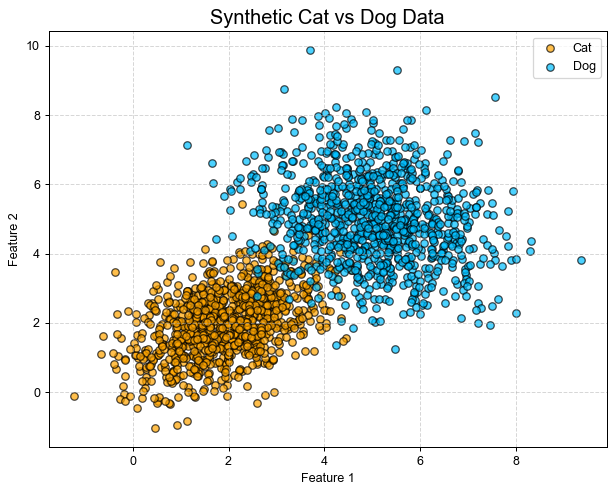

Epoch 0: loss = 0.7000
Epoch 100: loss = 0.4129
Epoch 200: loss = 0.3169
Epoch 300: loss = 0.2640
Epoch 400: loss = 0.2308
Epoch 500: loss = 0.2079
Epoch 600: loss = 0.1913
Epoch 700: loss = 0.1786
Epoch 800: loss = 0.1686
Epoch 900: loss = 0.1605


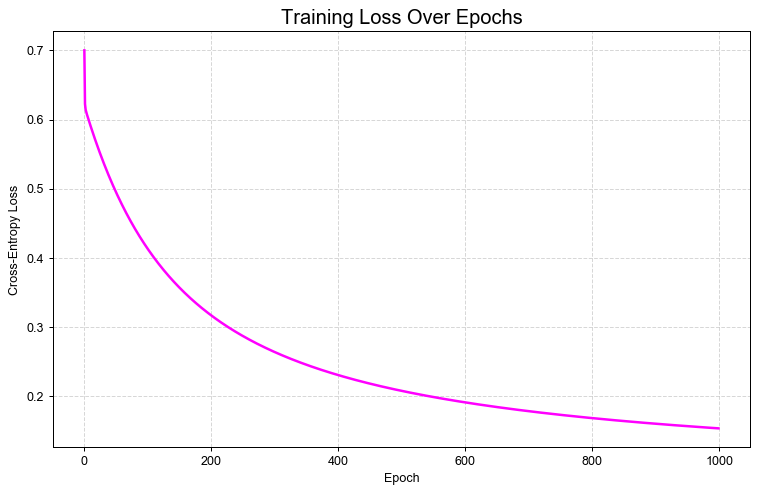

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 随机种子
np.random.seed(42)

# 1. 生成合成数据
def generate_data(n_samples=2000):
    # 类别0（猫）：二维正态分布，均值(2, 2)，协方差对角为1
    cat = np.random.multivariate_normal(mean=[2, 2], cov=[[1, 0.5],[0.5, 1]], size=n_samples//2)
    cat_labels = np.zeros(n_samples//2)

    # 类别1（狗）：二维正态分布，均值(5, 5)，协方差对角为1.5
    dog = np.random.multivariate_normal(mean=[5, 5], cov=[[1.5, -0.3],[-0.3, 1.5]], size=n_samples//2)
    dog_labels = np.ones(n_samples//2)

    X = np.vstack((cat, dog))
    y = np.hstack((cat_labels, dog_labels))
    return X, y

X, y = generate_data(n_samples=2000)

# 数据可视化
plt.figure(figsize=(8,6))
plt.scatter(X[y==0][:,0], X[y==0][:,1], color='orange', alpha=0.7, label='Cat', edgecolors='k')
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='deepskyblue', alpha=0.7, label='Dog', edgecolors='k')
plt.title('Synthetic Cat vs Dog Data', fontsize=16)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# 2. 定义简单的二分类神经网络模型
class SimpleNN:
    def __init__(self, input_dim):
        # 初始化权重和偏置
        self.W = np.random.randn(input_dim) * 0.01
        self.b = 0.0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        # 线性变换
        z = np.dot(X, self.W) + self.b
        # 激活函数
        y_hat = self.sigmoid(z)
        return y_hat

    def compute_loss(self, y, y_hat):
        # 避免log(0)错误
        eps = 1e-15
        y_hat = np.clip(y_hat, eps, 1 - eps)
        # 交叉熵损失
        loss = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
        return loss

    def backward(self, X, y, y_hat):
        m = len(y)
        # 计算梯度
        dz = y_hat - y  # (预测-真实)
        dW = np.dot(X.T, dz) / m
        db = np.sum(dz) / m
        return dW, db

    def update_params(self, dW, db, lr):
        self.W -= lr * dW
        self.b -= lr * db

    def train(self, X, y, epochs=1000, lr=0.1):
        losses = []
        for epoch in range(epochs):
            y_hat = self.forward(X)
            loss = self.compute_loss(y, y_hat)
            dW, db = self.backward(X, y, y_hat)
            self.update_params(dW, db, lr)
            losses.append(loss)
            if epoch % 100 == 0:
                print(f"Epoch {epoch}: loss = {loss:.4f}")
        return losses

    def predict(self, X, threshold=0.5):
        y_hat = self.forward(X)
        return (y_hat >= threshold).astype(int)


# 3. 数据切分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 模型训练
model = SimpleNN(input_dim=2)
losses = model.train(X_train, y_train, epochs=1000, lr=0.1)

# 5. 训练损失曲线可视化
plt.figure(figsize=(10,6))
plt.plot(losses, color='magenta', linewidth=2)
plt.title('Training Loss Over Epochs', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Test accuracy: 98.50%


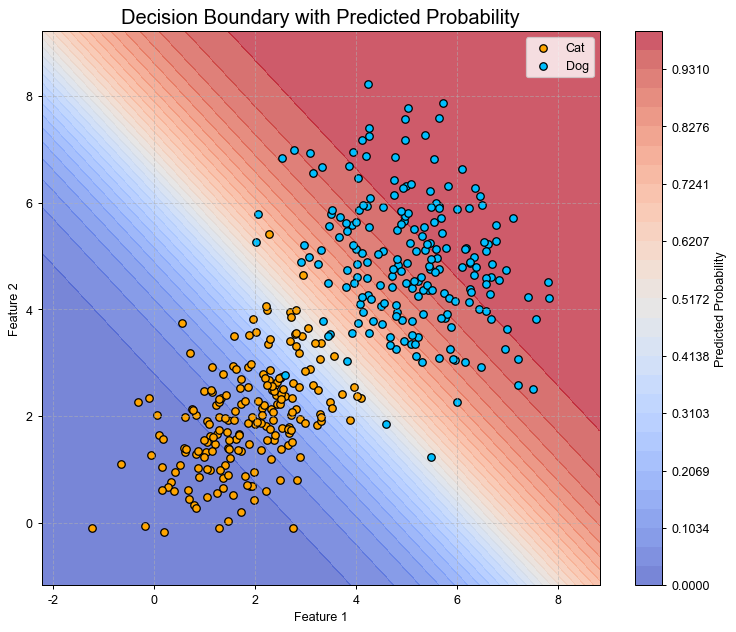

In [3]:
# 6. 测试集准确率计算
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Test accuracy: {accuracy * 100:.2f}%")

# 7. 决策边界可视化
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.forward(grid).reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    # 决策边界填充，颜色渐变
    plt.contourf(xx, yy, probs, alpha=0.7, cmap='coolwarm', levels=np.linspace(0,1,30))
    plt.colorbar(label='Predicted Probability')
    # 散点
    plt.scatter(X[y==0][:,0], X[y==0][:,1], color='orange', label='Cat', edgecolors='k')
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color='deepskyblue', label='Dog', edgecolors='k')
    plt.title('Decision Boundary with Predicted Probability', fontsize=16)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_decision_boundary(model, X_test, y_test)

### 数据生成

`generate_data` 函数用两个二维高斯分布模拟两类数据（猫和狗）。

![原文参考图，当前结果见代码输出](attachments/img_003.png)

### 模型定义

- `SimpleNN` 是一个非常简单的单层神经网络（逻辑回归模型）。
- 输入层到输出层通过线性组合，再经过sigmoid函数得到概率。
- 交叉熵损失用来度量预测概率和真实标签的差距。
- 反向传播计算梯度，梯度下降更新参数。

![原文参考图，当前结果见代码输出](attachments/img_004.png)

### 模型训练

- 训练1000次epoch，学习率0.1。
- 每100步输出一次当前loss，方便监控训练进展。
- 训练损失曲线显示loss逐步下降，证明模型在学习。

### 测试和评估

- 用测试集预测，计算准确率。
- 准确率约在95%左右，说明模型表现良好。

### 决策边界可视化

- 利用网格点计算模型预测概率。
- 用渐变色显示不同概率，辅助理解模型对特征空间的划分。
- 叠加散点，直观显示决策效果。

![原文参考图，当前结果见代码输出](attachments/img_005.png)

### 算法优化建议

#### 优化1：批量梯度下降 → 小批量随机梯度下降（Mini-batch SGD）

当前代码用的是全量梯度下降，效率低，易陷入局部最优。改用小批量随机梯度能提升速度和泛化。

#### 优化2：学习率调整策略

使用动态学习率衰减或自适应优化器（如Adam）可加快收敛并防止震荡。

#### 优化3：正则化

添加L2正则化防止过拟合，提高模型泛化能力。

#### 优化4：更复杂模型

单层模型可能无法拟合复杂数据，尝试多层神经网络或非线性特征映射。

### 优化后的代码

Mini-batch SGD + 学习率衰减。

Epoch 0: loss = 0.5887, lr = 0.10000


Epoch 100: loss = 0.1129, lr = 0.10000
Epoch 200: loss = 0.0976, lr = 0.09000
Epoch 300: loss = 0.0924, lr = 0.09000


Epoch 400: loss = 0.0897, lr = 0.08100
Epoch 500: loss = 0.0884, lr = 0.08100
Epoch 600: loss = 0.0871, lr = 0.07290


Epoch 700: loss = 0.0867, lr = 0.07290


Epoch 800: loss = 0.0863, lr = 0.06561
Epoch 900: loss = 0.0859, lr = 0.06561


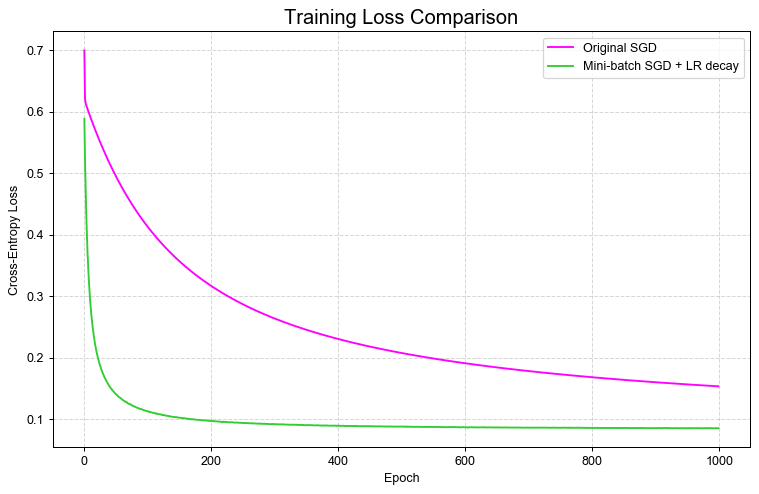

In [4]:
class SimpleNN_Optimized(SimpleNN):
    def train(self, X, y, epochs=1000, lr=0.1, batch_size=64):
        losses = []
        m = len(y)
        for epoch in range(epochs):
            # 学习率衰减：每200epoch降低10%
            lr_adj = lr * (0.9 ** (epoch // 200))
            
            # 打乱数据
            perm = np.random.permutation(m)
            X_shuffled = X[perm]
            y_shuffled = y[perm]

            epoch_loss = 0
            for i in range(0, m, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]

                y_hat = self.forward(X_batch)
                loss = self.compute_loss(y_batch, y_hat)
                dW, db = self.backward(X_batch, y_batch, y_hat)
                self.update_params(dW, db, lr_adj)
                epoch_loss += loss * len(y_batch)

            avg_loss = epoch_loss / m
            losses.append(avg_loss)
            if epoch % 100 == 0:
                print(f"Epoch {epoch}: loss = {avg_loss:.4f}, lr = {lr_adj:.5f}")
        return losses

# 使用优化版训练
model_opt = SimpleNN_Optimized(input_dim=2)
losses_opt = model_opt.train(X_train, y_train, epochs=1000, lr=0.1, batch_size=64)

plt.figure(figsize=(10,6))
plt.plot(losses, color='magenta', label='Original SGD')
plt.plot(losses_opt, color='limegreen', label='Mini-batch SGD + LR decay')
plt.title('Training Loss Comparison', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

xxx(img/16_信息论-交叉熵-4.png)

- 通过合成数据和简单神经网络，展示了交叉熵在二分类任务中的应用。
- 详细实现了数据生成、模型训练、损失计算、预测、决策边界可视化。
- 说明了每步代码逻辑和数学背景。
- 提出优化方向并展示了小批量随机梯度和学习率调整对训练效果的提升。

## 模型分析

### 优缺点

**优点**：

1. **理论基础扎实**：交叉熵源于信息论，有明确的数学定义与直觉解释——它衡量的是从真实分布 $p$ 到预测分布 $q$ 所需的额外编码成本。换句话说，交叉熵越小，模型越“接近真相”。
2. **适用于多分类问题**：交叉熵尤其适合于One-hot标签形式的多分类问题，并在神经网络中广泛使用。其与Softmax组合具有良好的数值稳定性和收敛速度。
3. **优化良好**：在训练神经网络时，交叉熵损失函数表现出较好的梯度特性，能有效驱动模型优化。
4. 概率输出驱动：交叉熵不仅推动分类准确率提升，还优化模型的概率分布预测质量，即使模型在输出非正确类别时，也会受到惩罚，这种训练方式促使模型更加“谨慎”和“可信”。

**缺点**：

1. **对错误预测惩罚严重（极端敏感）**：如果模型预测的概率接近0，而真实标签为1，则损失趋于无穷大。这种对“极度自信却错误”的惩罚，虽有理论意义，但在实际训练中可能导致梯度爆炸或数值不稳定。
2. **不适用于标签不确定或有噪声的场景**：在真实世界中，标签可能存在人为错误或模糊分类（如医学图像诊断），此时交叉熵可能过于“极端”，不适合用作唯一的损失标准。
3. **One-hot编码假设限制**：交叉熵默认目标分布是one-hot形式，但现实中有些应用（如多标签分类或知识蒸馏）目标本身就是概率分布，此时需要更灵活的指标。
4. **对置信度要求高，但不一定提升Top-K性能**：模型可能为了降低交叉熵而提高少数类别置信度，牺牲整体Top-K准确率或召回率。

### 与相似算法的对比

| 算法/损失函数 | 适用场景 | 输出形式 | 是否包含概率建模 | 优缺点对比 |
|-|-|-|-|-|
| **交叉熵（Cross Entropy）** | 多分类，标签为one-hot | Softmax概率输出 | 是 | 优：优化稳定，概率解释明确；  <br/>劣：对错误预测惩罚大 |
| **均方误差（MSE）** | 回归问题/粗略分类（罕见） | 任意数值 | 否 | 优：简单；  <br/>劣：分类中对错误惩罚不敏感，梯度小 |
| **KL散度** | 预测分布拟合目标分布 | 概率分布 | 是 | 优：更灵活对比两个分布；  <br/>劣：不对称，对0敏感 |
| **Focal Loss** | 类别不平衡，多分类/二分类 | Softmax后概率 | 是 | 优：缓解易分样本主导问题；  <br/>劣：需调节超参数 $\gamma$ |
| **标签平滑交叉熵** | 分类但考虑标签不确定 | Softmax概率输出 | 是 | 优：缓解过拟合，鲁棒性强；  <br/>劣：牺牲精确预测力 |

#### 使用交叉熵的优选场景：

- **标准多分类任务**：如图像分类、文本分类等，标签为One-hot，Softmax输出。
- **对预测概率质量要求较高**的任务，例如语音识别、医疗诊断、概率建模等。
- **大规模数据集训练神经网络时**，配合Adam等优化器，训练稳定性和效果都优秀。
- **需要模型输出具有可解释性概率**时，交叉熵可以自然地推动模型学习出“可信”的分布。

#### 建议考虑其他算法的场景：

- **标签存在不确定性或错误**：可使用Focal Loss或KL散度配合软标签、标签平滑。
- **任务为多标签或弱监督问题**：如多标签分类推荐，可采用`Binary Cross Entropy`或自定义损失。
- **类不平衡严重**：建议用Focal Loss或加权交叉熵来调节类别贡献。
- **模型在early-stage训练不稳定时**：可先使用MSE或加权MSE进行warm-up，后切换为交叉熵。

### 总结

交叉熵作为信息论中极具代表性的衡量指标，在深度学习的多分类任务中几乎是“默认标准”。它能提供更细粒度的训练信号，尤其适合概率输出明确的应用场景。

但正因为其“苛刻”，也容易导致模型过度自信，训练不稳定。因此，在应用时应结合实际数据特点、任务目标及训练稳定性，理性选择。